## 2-7_A_linear_model_in_the_presence_of_outliers

In [2]:
## 1. Import NumPy and Matplotlib for numerical operations and visualization.

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

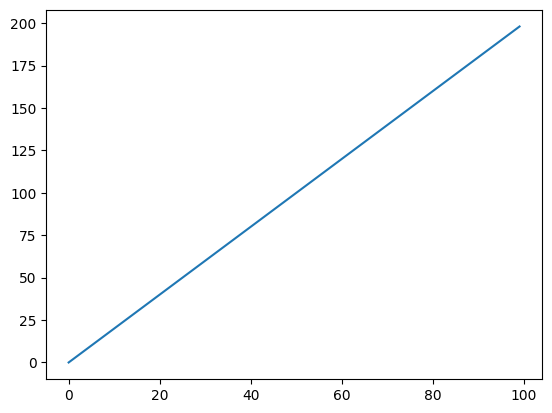

In [3]:
## 2. Generate a simple linear relationship as the ground truth.

num_points = 100

x_vals = np.arange(num_points)
y_truth = 2 * x_vals

plt.plot(x_vals, y_truth)

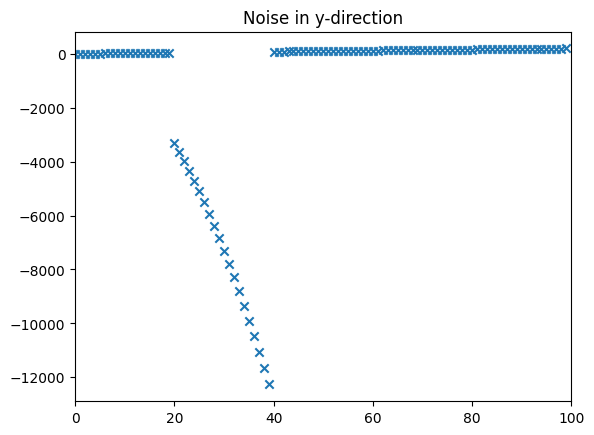

In [4]:
## 3. Introduce large outliers into part of the target values.

y_noisy = y_truth.copy()

# Change the y-values of some points to create outliers.
y_noisy[20:40] = (
    y_noisy[20:40] * (-4 * x_vals[20:40]) - 100
)

plt.title("Noise in y-direction")
plt.xlim([0, 100])
plt.scatter(x_vals, y_noisy, marker="x")

OLS  R-squared:  -904.7565621836717 Mean Absolute Error 1480.9397011701171
TSR  R-squared:  0.9999999999265342 Mean Absolute Error 0.00044250338446453574


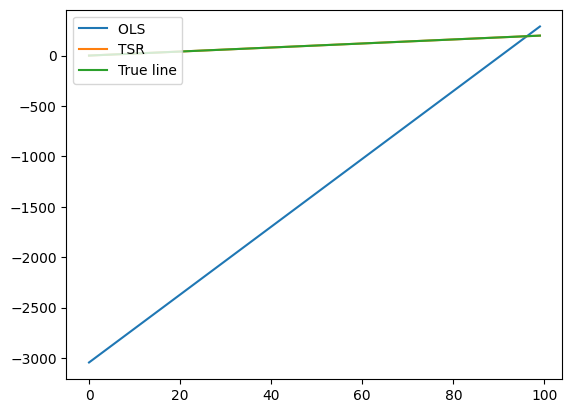

In [10]:
## 4. Compare ordinary least squares and Theil-Sen regression in the presence of outliers.

from sklearn.linear_model import LinearRegression, TheilSenRegressor
from sklearn.metrics import r2_score, mean_absolute_error

named_estimators = [('OLS ', LinearRegression()), ('TSR ', TheilSenRegressor())]

for num_index, est in enumerate(named_estimators):
    y_pred = est[1].fit(x_vals.reshape(-1, 1),y_noisy).predict(x_vals.reshape(-1, 1))
    print (est[0], "R-squared: ", r2_score(y_truth, y_pred), "Mean Absolute Error", mean_absolute_error(y_truth, y_pred))
    plt.plot(x_vals, y_pred, label=est[0])
plt.plot(x_vals, y_truth, label='True line')
plt.legend(loc='upper left')

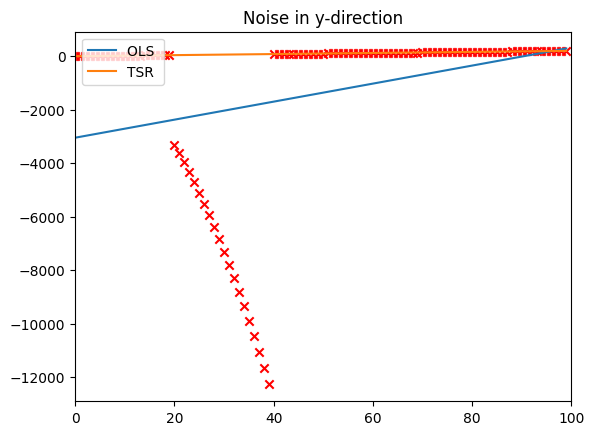

In [11]:
## 5. Visualize the noisy target values again.
for num_index, est in enumerate(named_estimators):
    y_pred = est[1].fit(x_vals.reshape(-1, 1),y_noisy).predict(x_vals.reshape(-1, 1))
    plt.plot(x_vals, y_pred, label=est[0])
plt.legend(loc='upper left')
plt.title("Noise in y-direction")
plt.xlim([0,100])
plt.scatter(x_vals, y_noisy,marker='x', color='red')

In [7]:
## 6. Compare multiple linear and robust regression models.

from sklearn.linear_model import (
    Ridge,
    LinearRegression,
    TheilSenRegressor,
    RANSACRegressor,
    ElasticNet,
    HuberRegressor
)

from sklearn.metrics import r2_score, mean_absolute_error

named_estimators = [
    ("OLS", LinearRegression()),
    ("Ridge", Ridge()),
    ("TSR", TheilSenRegressor(random_state=42)),
    ("RANSAC", RANSACRegressor(random_state=42)),
    ("ENet", ElasticNet()),
    ("Huber", HuberRegressor())
]

for name, estimator in named_estimators:
    y_pred = estimator.fit(
        x_vals.reshape(-1, 1),
        y_noisy
    ).predict(
        x_vals.reshape(-1, 1)
    )

    print(
        name,
        "R-squared:",
        r2_score(y_truth, y_pred),
        "Mean Absolute Error:",
        mean_absolute_error(y_truth, y_pred)
    )

OLS R-squared: -904.7565621836717 Mean Absolute Error: 1480.9397011701171
Ridge R-squared: -904.7501604538695 Mean Absolute Error: 1480.9385250222022
TSR R-squared: 0.9999999999265342 Mean Absolute Error: 0.00044250338446453574
RANSAC R-squared: 1.0 Mean Absolute Error: 0.0
ENet R-squared: -904.4272711687513 Mean Absolute Error: 1480.8791832083955
Huber R-squared: 0.9999999867470235 Mean Absolute Error: 0.0066449711785321885
